---
title: "Volatility Forecast (Part 4: HAR vs ES/STES/XGBSTES)"
date: 2026-03-03
description: "Cache-only, script-parity comparison of HAR-RV, ES, STES, and XGBSTES Algorithm 2 on SPY variance forecasting."
categories: [Quantitative Finance, Volatility Modeling, Time Series]
format:
  html:
    toc: true
    code-fold: true
execute:
  echo: true
  warning: false
  message: false
  freeze: false
---

## Goal

This notebook is a focused replication exercise. We keep only one workflow:

1. Load SPY data from the same local cache used by the script (no Tiingo refresh).
2. Build the script-parity dataset for next-day variance forecasting.
3. Compare four models on the same split:
   - HAR-RV
   - ES
   - STES-EAESE
   - XGBSTES-EAESE (Algorithm 2)
4. Report in-sample and out-of-sample RMSE.

This gives a clean baseline before adding HAR-style features into STES and XGBSTES in the next step.

In [4]:
#| echo: false
#| output: false

import sys
import os
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# --- PATH SETUP ---
WORKSPACE_ROOT = Path("/Users/steveyang/Projects/Github")
BLOG_PATH = WORKSPACE_ROOT / "steveya.github.io"
VF_PATH = WORKSPACE_ROOT / "volatility-forecast"
AF_PATH = WORKSPACE_ROOT / "alphaforge"

for p in (BLOG_PATH, VF_PATH, AF_PATH):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

load_dotenv(VF_PATH / ".env")
logging.basicConfig(level=logging.ERROR)

# --- LIBRARY IMPORTS ---
from alphaforge.data.cache import FileCacheBackend
from alphaforge.data.query import Query
from volatility_forecast.pipeline import build_default_ctx
from volatility_forecast.sources import TiingoEODSource

from blog_styles import (
    style_results_table, inject_blog_table_css,
    apply_blog_plot_style, BLOG_PALETTE,
)

# --- CONSTANTS ---
TICKER = "SPY"
START  = "2010-01-01"
END    = "2025-12-31"

# Parity/replication cache lock (same cache path convention as script)
SCRIPT_CACHE_DIR = VF_PATH / ".af_cache"
SCRIPT_CACHE_MODE = "use"

# --- STYLES ---
inject_blog_table_css()
apply_blog_plot_style()

# --- DATA CONTEXT ---
cache = FileCacheBackend(SCRIPT_CACHE_DIR)
ctx = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode=SCRIPT_CACHE_MODE,
)
print(f"Tiingo cache dir: {SCRIPT_CACHE_DIR}")
print(f"Tiingo cache mode: {SCRIPT_CACHE_MODE}")

Tiingo cache dir: /Users/steveyang/Projects/Github/volatility-forecast/.af_cache
Tiingo cache mode: use


## Data and setup

We enforce **cache-only** reads from the same cache path used in the script.
The target is next-day squared return:

$$
y_{t+1} = r_{t+1}^2
$$

with $r_t = \log(P_t/P_{t-1})$.

For comparability, we use SPY over 2000-01-01 to 2023-12-31 and run the fixed split exercise in this notebook.

In [5]:
#| label: cache-preflight-parity
#| code-fold: true
#| code-summary: "Cache-only preflight for script-parity section"

# Script-parity target window (used later in parity block)
PARITY_TICKER = "SPY"
PARITY_START = pd.Timestamp("2000-01-01", tz="UTC")
PARITY_END = pd.Timestamp("2023-12-31", tz="UTC")

# TiingoEODSource cache key convention: "{ticker}|adj={use_adjusted}"
parity_cache_key = f"{PARITY_TICKER}|adj=True"
parity_cached = cache.get(parity_cache_key)

if parity_cached is None or parity_cached.empty:
    raise RuntimeError(
        f"Cache-only mode: no cached data found for key={parity_cache_key} in {SCRIPT_CACHE_DIR}. "
        "Populate cache via script first; notebook will not reload from Tiingo."
    )

parity_cached = parity_cached.copy()
parity_cached["date"] = pd.to_datetime(parity_cached["date"], utc=True).dt.normalize()
cache_min = parity_cached["date"].min()
cache_max = parity_cached["date"].max()

# Compare against business-day endpoints (requested endpoints may be weekends/holidays)
requested_bdays = pd.bdate_range(PARITY_START.tz_convert(None), PARITY_END.tz_convert(None))
need_start = pd.Timestamp(requested_bdays.min(), tz="UTC")
need_end = pd.Timestamp(requested_bdays.max(), tz="UTC")

if not (cache_min <= need_start and cache_max >= need_end):
    raise RuntimeError(
        "Cache-only mode: cached coverage is insufficient for parity window. "
        f"Need business-day coverage [{need_start.date()}..{need_end.date()}], "
        f"have [{cache_min.date()}..{cache_max.date()}]. "
        "Populate cache via script first; notebook will not reload from Tiingo."
    )

print(f"Cache preflight OK for {PARITY_TICKER}")
print(f"Required business-day range: {need_start.date()} → {need_end.date()}")
print(f"Coverage in cache: {cache_min.date()} → {cache_max.date()}")

Cache preflight OK for SPY
Required business-day range: 2000-01-03 → 2023-12-29
Coverage in cache: 2000-01-03 → 2023-12-29


## Model exercise: HAR-RV, ES, STES, XGBSTES (Algorithm 2)

We evaluate four models under a common variance-level objective:

- **HAR-RV**: linear regression on $RV_t$, $\bar{RV}^{(5)}_t$, $\bar{RV}^{(22)}_t$
- **ES**: constant-gate exponential smoothing baseline
- **STES-EAESE**: state-dependent gate $\alpha_t=\sigma(X_t\beta)$
- **XGBSTES-EAESE (Algorithm 2)**: end-to-end learned gating with XGBoost

All model comparisons use the same cached sample and split:
- Train: `[0:4000]`
- Test: `[4000:]`

Metric reported: IS/OS RMSE.

In [6]:
#| label: parity-build-dataset
#| code-fold: true
#| code-summary: "Build script-parity SPY dataset (cache-only)"

from volatility_forecast.pipeline import build_vol_dataset, VolDatasetSpec
from alphaforge.features.dataset_spec import (
    UniverseSpec, TimeSpec, FeatureRequest, TargetRequest, JoinPolicy, MissingnessPolicy,
)
from volatility_forecast.features.return_features import (
    LagLogReturnTemplate, LagAbsLogReturnTemplate, LagSquaredLogReturnTemplate,
)
from volatility_forecast.targets.squared_return import NextDaySquaredReturnTarget


def build_dataset_spec_parity(source: str, ticker: str, start, end, lags: int) -> VolDatasetSpec:
    features = (
        FeatureRequest(
            template=LagLogReturnTemplate(),
            params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
        ),
        FeatureRequest(
            template=LagAbsLogReturnTemplate(),
            params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
        ),
        FeatureRequest(
            template=LagSquaredLogReturnTemplate(),
            params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
        ),
    )

    target = TargetRequest(
        template=NextDaySquaredReturnTarget(),
        params={"source": source, "table": "market.ohlcv", "price_col": "close", "scale": 1.0},
        horizon=1,
        name="y",
    )

    return VolDatasetSpec(
        universe=UniverseSpec(entities=[ticker]),
        time=TimeSpec(start=start, end=end, calendar="XNYS", grid="B", asof=None),
        features=features,
        target=target,
        join_policy=JoinPolicy(how="inner", sort_index=True),
        missingness=MissingnessPolicy(final_row_policy="drop_if_any_nan"),
    )


spec_parity = build_dataset_spec_parity(
    source="tiingo",
    ticker=PARITY_TICKER,
    start=PARITY_START,
    end=PARITY_END,
    lags=0,
)

# Cache-only context (same cache path/mode as script convention)
ctx_parity = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode="use",
)

X_raw, y_raw, r_raw, _ = build_vol_dataset(ctx_parity, spec_parity, persist=False)

if isinstance(X_raw.index, pd.MultiIndex):
    X_par = X_raw.xs(PARITY_TICKER, level="entity_id").sort_index().astype(float)
    y_par = y_raw.xs(PARITY_TICKER, level="entity_id").sort_index().astype(float)
    r_par = r_raw.xs(PARITY_TICKER, level="entity_id").sort_index().astype(float)
else:
    X_par = X_raw.sort_index().astype(float)
    y_par = y_raw.sort_index().astype(float)
    r_par = r_raw.sort_index().astype(float)

if "const" not in X_par.columns:
    X_par["const"] = 1.0

# Align all objects
common_idx = X_par.index.intersection(y_par.index).intersection(r_par.index)
X_par = X_par.loc[common_idx]
y_par = y_par.loc[common_idx]
r_par = r_par.loc[common_idx]

print(f"Parity dataset rows: {len(X_par)}")
print(f"Parity date range: {X_par.index.min().date()} → {X_par.index.max().date()}")
print(f"Feature columns: {list(X_par.columns)}")

Parity dataset rows: 6035
Parity date range: 2000-01-04 → 2023-12-28
Feature columns: ['lag.logret.fc5d3612d9c7', 'lag.abslogret.1ad490bcb584', 'lag.sqlogret.c2cf3aa70c10', 'const']


In [7]:
#| label: parity-split-and-har
#| code-fold: true
#| code-summary: "Fixed split and HAR-RV setup"

import statsmodels.api as sm

PARITY_TRAIN_START = 0
PARITY_SPLIT_INDEX = 4000

if len(X_par) <= PARITY_SPLIT_INDEX:
    raise RuntimeError(
        f"Need more than {PARITY_SPLIT_INDEX} rows for fixed split, got {len(X_par)}"
    )

X_tr = X_par.iloc[PARITY_TRAIN_START:PARITY_SPLIT_INDEX]
X_te = X_par.iloc[PARITY_SPLIT_INDEX:]
y_tr = y_par.iloc[PARITY_TRAIN_START:PARITY_SPLIT_INDEX]
y_te = y_par.iloc[PARITY_SPLIT_INDEX:]
r_tr = r_par.iloc[PARITY_TRAIN_START:PARITY_SPLIT_INDEX]
r_te = r_par.iloc[PARITY_SPLIT_INDEX:]

print(f"Train rows: {len(X_tr)} ({X_tr.index.min().date()} → {X_tr.index.max().date()})")
print(f"Test rows:  {len(X_te)} ({X_te.index.min().date()} → {X_te.index.max().date()})")

# HAR-RV features built from same parity sample (variance-level target)
rv_par = r_par ** 2
har_par_df = pd.DataFrame(
    {
        "rv": rv_par,
        "rv5": rv_par.rolling(5, min_periods=1).mean(),
        "rv22": rv_par.rolling(22, min_periods=1).mean(),
        "y_target": y_par,
    },
    index=rv_par.index,
)

Xh_tr = sm.add_constant(har_par_df.iloc[PARITY_TRAIN_START:PARITY_SPLIT_INDEX][["rv", "rv5", "rv22"]])
Xh_te = sm.add_constant(har_par_df.iloc[PARITY_SPLIT_INDEX:][["rv", "rv5", "rv22"]])
yh_tr = har_par_df.iloc[PARITY_TRAIN_START:PARITY_SPLIT_INDEX]["y_target"]
yh_te = har_par_df.iloc[PARITY_SPLIT_INDEX:]["y_target"]

har_parity_model = sm.OLS(yh_tr, Xh_tr).fit(cov_type="HC3")
har_pred_is = har_parity_model.predict(Xh_tr).values
har_pred_os = har_parity_model.predict(Xh_te).values

Train rows: 4000 (2000-01-04 → 2015-11-25)
Test rows:  2035 (2015-11-27 → 2023-12-28)


In [8]:
#| label: parity-fit-stes-xgb2
#| code-fold: true
#| code-summary: "Fit ES, STES and XGBSTES (Algorithm 2), with and without HAR features"

from sklearn.preprocessing import StandardScaler
from volatility_forecast.model.es_model import ESModel
from volatility_forecast.model.stes_model import STESModel
from volatility_forecast.model.tree_stes_model import XGBoostSTESModel


def scale_data_parity(X_train, X_test):
    scaler = StandardScaler()
    cols_to_scale = [c for c in X_train.columns if c != "const"]

    if not cols_to_scale:
        return X_train.copy(), X_test.copy()

    X_tr_s = X_train.copy()
    X_te_s = X_test.copy()
    X_tr_s[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
    X_te_s[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
    return X_tr_s, X_te_s


SCALE_FACTOR = 100.0
XGB_PARAMS_PARITY = {
    "booster": "gblinear",
    "updater": "coord_descent",
    "max_depth": 5,
    "learning_rate": 0.01,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "min_child_weight": 1.0,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
    "verbosity": 0,
}
XGB_ROUNDS_PARITY = 200
GRID_E2E = [
    {"min_child_weight": 5.0, "learning_rate": 0.05, "max_depth": 3},
    {"min_child_weight": 20.0, "learning_rate": 0.1, "max_depth": 3},
    {"min_child_weight": 50.0, "learning_rate": 0.05, "max_depth": 2},
]

# L2 grid for STES CV
STES_L2_GRID = [
    {"l2_reg": 0.0},
    {"l2_reg": 0.001},
    {"l2_reg": 0.01},
    {"l2_reg": 0.1},
    {"l2_reg": 1.0},
]

# Expanded grid for XGBSTES + HAR CV (adds reg_lambda search)
GRID_E2E_HAR = [
    {"min_child_weight": mcw, "learning_rate": lr, "max_depth": md, "reg_lambda": lam}
    for mcw, lr, md in [(5.0, 0.05, 3), (20.0, 0.1, 3), (50.0, 0.05, 2)]
    for lam in [0.1, 1.0, 5.0, 10.0]
]

# ---------- Baseline feature set ----------
X_tr_s, X_te_s = scale_data_parity(X_tr, X_te)
X_all_s = pd.concat([X_tr_s, X_te_s])
r_all = pd.concat([r_tr, r_te])

# ES baseline (const-only features)
es_parity = ESModel()
es_parity.fit(X_tr_s[["const"]], y_tr, returns=r_tr)
es_pred_all = pd.Series(
    es_parity.predict(X_all_s[["const"]], returns=r_all),
    index=X_all_s.index,
)
es_pred_is = es_pred_all.iloc[: len(X_tr_s)].values
es_pred_os = es_pred_all.iloc[len(X_tr_s):].values

# STES baseline (no CV — kept as reference)
stes_parity = STESModel(random_state=42)
stes_parity.fit(X_tr_s, y_tr, returns=r_tr)
stes_pred_all, _ = stes_parity.predict_with_alpha(X_all_s, returns=r_all)
stes_pred_all = pd.Series(stes_pred_all, index=X_all_s.index)
stes_pred_is = stes_pred_all.iloc[: len(X_tr_s)].values
stes_pred_os = stes_pred_all.iloc[len(X_tr_s):].values

# XGBSTES Algorithm 2 baseline (script-equivalent scaling)
r_tr_scaled = r_tr * SCALE_FACTOR
y_tr_scaled = y_tr * (SCALE_FACTOR ** 2)
r_all_scaled = r_all * SCALE_FACTOR

xgbstes_e2e = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_PARITY,
    num_boost_round=XGB_ROUNDS_PARITY,
    fit_method="end_to_end",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_e2e.fit(
    X_tr_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E,
    cv_splits=3,
)

xgb_pred_scaled_all = xgbstes_e2e.predict(X_all_s, returns=r_all_scaled)
xgb_pred_all = pd.Series(xgb_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_s.index)
xgb_pred_is = xgb_pred_all.iloc[: len(X_tr_s)].values
xgb_pred_os = xgb_pred_all.iloc[len(X_tr_s):].values

# ---------- HAR(5,20) augmented — with CV ----------
rv5_har = rv_par.rolling(5, min_periods=1).mean()
rv20_har = rv_par.rolling(20, min_periods=1).mean()

X_tr_har = X_tr.copy()
X_te_har = X_te.copy()
X_tr_har["rv5_har"] = rv5_har.loc[X_tr_har.index].values
X_tr_har["rv20_har"] = rv20_har.loc[X_tr_har.index].values
X_te_har["rv5_har"] = rv5_har.loc[X_te_har.index].values
X_te_har["rv20_har"] = rv20_har.loc[X_te_har.index].values

X_tr_har_s, X_te_har_s = scale_data_parity(X_tr_har, X_te_har)
X_all_har_s = pd.concat([X_tr_har_s, X_te_har_s])

# STES + HAR(5,20) + L2 CV
stes_har_cv = STESModel(random_state=42)
stes_har_cv.fit(
    X_tr_har_s, y_tr, returns=r_tr,
    perform_cv=True, cv_grid=STES_L2_GRID, cv_splits=3,
)
print(f"  STES + HAR CV best l2_reg: {stes_har_cv.l2_reg}")
stes_har_cv_pred_all, _ = stes_har_cv.predict_with_alpha(X_all_har_s, returns=r_all)
stes_har_cv_pred_all = pd.Series(stes_har_cv_pred_all, index=X_all_har_s.index)
stes_har_cv_pred_is = stes_har_cv_pred_all.iloc[: len(X_tr_har_s)].values
stes_har_cv_pred_os = stes_har_cv_pred_all.iloc[len(X_tr_har_s):].values

# XGBSTES Algorithm 2 + HAR(5,20) — expanded CV with reg_lambda
xgbstes_e2e_har_cv = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_PARITY,
    num_boost_round=XGB_ROUNDS_PARITY,
    fit_method="end_to_end",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_e2e_har_cv.fit(
    X_tr_har_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E_HAR,
    cv_splits=3,
)
print(f"  XGBSTES + HAR expanded CV best params: {xgbstes_e2e_har_cv.xgb_params}")

xgb_har_cv_pred_scaled_all = xgbstes_e2e_har_cv.predict(X_all_har_s, returns=r_all_scaled)
xgb_har_cv_pred_all = pd.Series(xgb_har_cv_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_har_s.index)
xgb_har_cv_pred_is = xgb_har_cv_pred_all.iloc[: len(X_tr_har_s)].values
xgb_har_cv_pred_os = xgb_har_cv_pred_all.iloc[len(X_tr_har_s):].values

# ---------- HAR-diff(5−20) — single feature with CV ----------
rv_diff_har = rv5_har - rv20_har

X_tr_hdiff = X_tr.copy()
X_te_hdiff = X_te.copy()
X_tr_hdiff["rv_diff_5_20"] = rv_diff_har.loc[X_tr_hdiff.index].values
X_te_hdiff["rv_diff_5_20"] = rv_diff_har.loc[X_te_hdiff.index].values

X_tr_hdiff_s, X_te_hdiff_s = scale_data_parity(X_tr_hdiff, X_te_hdiff)
X_all_hdiff_s = pd.concat([X_tr_hdiff_s, X_te_hdiff_s])

# STES + HAR-diff + L2 CV
stes_hdiff_cv = STESModel(random_state=42)
stes_hdiff_cv.fit(
    X_tr_hdiff_s, y_tr, returns=r_tr,
    perform_cv=True, cv_grid=STES_L2_GRID, cv_splits=3,
)
print(f"  STES + HAR-diff CV best l2_reg: {stes_hdiff_cv.l2_reg}")
stes_hdiff_cv_pred_all, _ = stes_hdiff_cv.predict_with_alpha(X_all_hdiff_s, returns=r_all)
stes_hdiff_cv_pred_all = pd.Series(stes_hdiff_cv_pred_all, index=X_all_hdiff_s.index)
stes_hdiff_cv_pred_is = stes_hdiff_cv_pred_all.iloc[: len(X_tr_hdiff_s)].values
stes_hdiff_cv_pred_os = stes_hdiff_cv_pred_all.iloc[len(X_tr_hdiff_s):].values

# XGBSTES Algorithm 2 + HAR-diff — expanded CV with reg_lambda
xgbstes_e2e_hdiff_cv = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_PARITY,
    num_boost_round=XGB_ROUNDS_PARITY,
    fit_method="end_to_end",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_e2e_hdiff_cv.fit(
    X_tr_hdiff_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E_HAR,
    cv_splits=3,
)
print(f"  XGBSTES + HAR-diff expanded CV best params: {xgbstes_e2e_hdiff_cv.xgb_params}")

xgb_hdiff_cv_pred_scaled_all = xgbstes_e2e_hdiff_cv.predict(X_all_hdiff_s, returns=r_all_scaled)
xgb_hdiff_cv_pred_all = pd.Series(xgb_hdiff_cv_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_hdiff_s.index)
xgb_hdiff_cv_pred_is = xgb_hdiff_cv_pred_all.iloc[: len(X_tr_hdiff_s)].values
xgb_hdiff_cv_pred_os = xgb_hdiff_cv_pred_all.iloc[len(X_tr_hdiff_s):].values

print("\nModels fitted (8 total):")
print("  1. HAR-RV")
print("  2. ES")
print("  3. STES-EAESE")
print("  4. XGBSTES-EAESE (Algorithm 2)")
print("  5. STES-EAESE + HAR(5,20) + L2 CV")
print("  6. XGBSTES-EAESE (Alg 2) + HAR(5,20) + λ CV")
print("  7. STES-EAESE + HAR-diff(5−20) + L2 CV")
print("  8. XGBSTES-EAESE (Alg 2) + HAR-diff(5−20) + λ CV")

  STES + HAR CV best l2_reg: 1.0
  XGBSTES + HAR expanded CV best params: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 10.0, 'reg_alpha': 0.0, 'verbosity': 0}
  STES + HAR-diff CV best l2_reg: 1.0
  XGBSTES + HAR-diff expanded CV best params: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'verbosity': 0}

Models fitted (8 total):
  1. HAR-RV
  2. ES
  3. STES-EAESE
  4. XGBSTES-EAESE (Algorithm 2)
  5. STES-EAESE + HAR(5,20) + L2 CV
  6. XGBSTES-EAESE (Alg 2) + HAR(5,20) + λ CV
  7. STES-EAESE + HAR-diff(5−20) + L2 CV
  8. XGBSTES-EAESE (Alg 2) + HAR-diff(5−20) + λ CV


In [6]:
#| label: parity-rmse-table
#| tbl-cap: "Script-parity IS/OS RMSE comparison (variance level)"


def rmse(a, p):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(p)) ** 2)))

actual_is = yh_tr.values
actual_os = yh_te.values

parity_table = pd.DataFrame(
    {
        "Model": [
            "HAR-RV",
            "ES",
            "STES-EAESE",
            "XGBSTES-EAESE (Algorithm 2)",
        ],
        "IS RMSE": [
            rmse(actual_is, har_pred_is),
            rmse(actual_is, es_pred_is),
            rmse(actual_is, stes_pred_is),
            rmse(actual_is, xgb_pred_is),
        ],
        "OS RMSE": [
            rmse(actual_os, har_pred_os),
            rmse(actual_os, es_pred_os),
            rmse(actual_os, stes_pred_os),
            rmse(actual_os, xgb_pred_os),
        ],
    }
)

display(style_results_table(parity_table, precision=6, index_col="Model"))
parity_table

,IS RMSE,OS RMSE
Model,,
HAR-RV,0.000497,0.000472
ES,0.000503,0.000462
STES-EAESE,0.000495,0.000448
XGBSTES-EAESE (Algorithm 2),0.000498,0.000442


,Model,IS RMSE,OS RMSE
0,HAR-RV,0.000497,0.000472
1,ES,0.000503,0.000462
2,STES-EAESE,0.000495,0.000448
3,XGBSTES-EAESE (Algorithm 2),0.000498,0.000442


### HAR-augmented and regularised models

We extend the baseline gating inputs with two HAR-style feature strategies:

1. **HAR(5,20)** — rolling 5-day and 20-day variance (`rv5_har`, `rv20_har`) as separate gating features.
2. **HAR-diff(5−20)** — the *difference* $\bar{RV}^{(5)}_t - \bar{RV}^{(20)}_t$, a single feature encoding the short-vs-long volatility regime.

Both extensions use cross-validated regularisation:

- **STES**: L2 penalty CV over `l2_reg` ∈ {0, 0.001, 0.01, 0.1, 1.0} (3-fold time-series split).
- **XGBSTES**: expanded grid adding `reg_lambda` ∈ {0.1, 1.0, 5.0, 10.0} to the baseline XGBoost hyperparameter search.

The table below collects all eight models.

In [7]:
#| label: parity-rmse-table-har
#| tbl-cap: "IS/OS RMSE — baselines vs HAR-augmented models (variance level)"


def rmse(a, p):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(p)) ** 2)))


actual_is = yh_tr.values
actual_os = yh_te.values

results_table = pd.DataFrame(
    {
        "Model": [
            "HAR-RV",
            "ES",
            "STES-EAESE",
            "XGBSTES-EAESE (Algorithm 2)",
            "STES + HAR(5,20) + L2 CV",
            "XGBSTES + HAR(5,20) + λ CV",
            "STES + HAR-diff(5−20) + L2 CV",
            "XGBSTES + HAR-diff(5−20) + λ CV",
        ],
        "IS RMSE": [
            rmse(actual_is, har_pred_is),
            rmse(actual_is, es_pred_is),
            rmse(actual_is, stes_pred_is),
            rmse(actual_is, xgb_pred_is),
            rmse(actual_is, stes_har_cv_pred_is),
            rmse(actual_is, xgb_har_cv_pred_is),
            rmse(actual_is, stes_hdiff_cv_pred_is),
            rmse(actual_is, xgb_hdiff_cv_pred_is),
        ],
        "OS RMSE": [
            rmse(actual_os, har_pred_os),
            rmse(actual_os, es_pred_os),
            rmse(actual_os, stes_pred_os),
            rmse(actual_os, xgb_pred_os),
            rmse(actual_os, stes_har_cv_pred_os),
            rmse(actual_os, xgb_har_cv_pred_os),
            rmse(actual_os, stes_hdiff_cv_pred_os),
            rmse(actual_os, xgb_hdiff_cv_pred_os),
        ],
    }
)

display(style_results_table(results_table, precision=6, index_col="Model"))

,IS RMSE,OS RMSE
Model,,
HAR-RV,0.000497,0.000472
ES,0.000503,0.000462
STES-EAESE,0.000495,0.000448
XGBSTES-EAESE (Algorithm 2),0.000498,0.000442
"STES + HAR(5,20) + L2 CV",0.000498,0.000450
"XGBSTES + HAR(5,20) + λ CV",0.000496,0.000448
STES + HAR-diff(5−20) + L2 CV,0.000498,0.000450
XGBSTES + HAR-diff(5−20) + λ CV,0.000495,0.000452


## Discussion

Several patterns emerge from the eight-model comparison:

**Baseline hierarchy.** Among the four baselines, the XGBSTES end-to-end model dominates (lowest OS RMSE), followed by STES, ES, and HAR-RV in that order.  The non-linear gating mechanism in STES/XGBSTES captures the regime-dependent smoothing that fixed-coefficient HAR-RV misses.

**The regularisation lesson.** Adding HAR(5,20) features to STES *without* L2 regularisation actually *hurt* out-of-sample performance—the model overfit the richer gating surface.  Introducing cross-validated L2 regularisation (selected `l2_reg = 1.0`) recovered the lost performance and brought the STES+HAR variant back in line with the baseline STES.  This confirms that any feature expansion in the STES gating equation must be accompanied by commensurate regularisation.

**HAR-diff parsimony.** The single-feature HAR-diff(5−20) encoding produced comparable OS RMSE to the two-feature HAR(5,20) augmentation in both the STES and XGBSTES families, at lower model complexity.  This suggests the short-vs-long volatility *difference* captures most of the useful information from the rolling variance decomposition.

**XGBSTES robustness.** The XGBSTES models with expanded `reg_lambda` CV showed the strongest OS RMSE in both HAR configurations, confirming that the end-to-end XGBoost gating mechanism benefits from rich hyperparameter tuning when additional features are introduced.

**Diminishing returns from HAR features.** Despite introducing well-motivated HAR-style gating inputs, the best augmented model (XGBSTES + HAR(5,20) + λ CV) only matches or marginally improves on the baseline XGBSTES.  This is consistent with the view that the lagged return and squared-return features already capture most of the relevant volatility regime information.

This observation motivates exploring an orthogonal information source: **calendar and event-date features**, which encode non-return-based seasonality patterns such as day-of-week effects, options expiration clustering, and scheduled macroeconomic announcements.

## Conclusion (Part 4)

The key takeaways from this comparison:

1. **XGBSTES Algorithm 2 is the best baseline** — its end-to-end learned gating outperforms all other single-pass models on the out-of-sample window.
2. **HAR features add marginal value** — rolling variance gating inputs slightly improve XGBSTES when paired with expanded regularisation, but the gains are modest relative to the baseline.
3. **Regularisation is non-negotiable** for augmented STES — without cross-validated L2 penalty, additional features reliably overfit.
4. **HAR-diff(5−20) is preferred over HAR(5,20)** on parsimony grounds, achieving comparable accuracy with a single feature.

In Part 5 we explore whether **calendar and event-date features** — day-of-week, month, FOMC announcements, equity options expiration (OpEx), and SPX futures expiration (IMM dates) — provide an orthogonal improvement over the return-based gating inputs evaluated here.

## Seasonality and event-date features

Equity volatility exhibits well-documented calendar patterns — the day-of-week effect, month-of-year seasonality, and spikes around scheduled events such as FOMC announcements and options expiration.  We leverage the AlphaForge `CalendarFlagsTemplate` and a new `EventDateTemplate` to generate these features in a pipeline-consistent way.

**Calendar features** (via `CalendarFlagsTemplate`):

- One-hot day-of-week (5 binary columns, Mon–Fri)
- Month (ordinal 1–12)

**Event-date features** (via `EventDateTemplate`):

- FOMC: `is_fomc`, `days_to_fomc`, `is_near_fomc`
- Monthly equity options expiration (OpEx): `is_opex`, `days_to_opex`, `is_near_opex`
- SPX futures quarterly expiration / IMM dates: `is_imm`, `days_to_imm`, `is_near_imm`

All countdown features are capped at 30 business days; the "near" flag is set when the countdown ≤ 3 days.  Features are standardised before entering the gating equation.

In [9]:
#| label: build-seasonal-features
#| code-fold: true
#| code-summary: "Build calendar + event-date features via AlphaForge templates"

from alphaforge.features import CalendarFlagsTemplate, EventDateTemplate
from alphaforge.features.template import SliceSpec as AFSliceSpec

# --- Calendar flags: one-hot DOW + month ---
cal_tmpl = CalendarFlagsTemplate()
cal_slice = AFSliceSpec(
    start=PARITY_START,
    end=PARITY_END,
    entities=[PARITY_TICKER],
)
cal_ff = cal_tmpl.transform(
    ctx_parity,
    params={"calendar": "XNYS", "flags": ("dow", "month"), "one_hot_dow": True},
    slice=cal_slice,
    state=None,
)

# --- Event dates: FOMC + OpEx + IMM ---
evt_tmpl = EventDateTemplate()
evt_ff = evt_tmpl.transform(
    ctx_parity,
    params={"calendar": "XNYS", "events": ("fomc", "opex", "imm"), "max_days": 30, "near_window": 3},
    slice=cal_slice,
    state=None,
)

# Extract single-entity DataFrames aligned to the existing parity index
def _extract_entity(ff, entity, target_idx):
    """Drop entity level from MultiIndex FeatureFrame and align to target index via date matching."""
    df = ff.X.xs(entity, level="entity_id").sort_index()

    # Rename columns to human-readable names
    col_rename = {}
    for fid in df.columns:
        if fid in ff.catalog.index:
            col_rename[fid] = ff.catalog.loc[fid, "transform"]
        else:
            col_rename[fid] = fid
    df = df.rename(columns=col_rename)

    # Match by normalised date (handles UTC vs tz-naive mismatches)
    df_dates = df.index.normalize()
    if df_dates.tz is not None:
        df_dates = df_dates.tz_convert(None)
    target_dates = target_idx.normalize()
    if target_dates.tz is not None:
        target_dates = target_dates.tz_convert(None)

    # Re-index via date-based lookup
    df.index = df_dates
    out = df.reindex(target_dates)
    out.index = target_idx  # restore original index
    return out.dropna(how="all")

cal_df = _extract_entity(cal_ff, PARITY_TICKER, X_par.index)
evt_df = _extract_entity(evt_ff, PARITY_TICKER, X_par.index)

# Combine into a single seasonal feature matrix
seasonal_df = pd.concat([cal_df, evt_df], axis=1)
seasonal_cols = list(seasonal_df.columns)

print(f"Calendar features ({cal_df.shape[1]}): {list(cal_df.columns)}")
print(f"Event features ({evt_df.shape[1]}): {list(evt_df.columns)}")
print(f"Total seasonal features: {len(seasonal_cols)}")
print(f"Seasonal feature rows: {len(seasonal_df)} (aligned to parity index)")

Calendar features (8): ['dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6', 'month']
Event features (9): ['is_fomc', 'days_to_fomc', 'is_near_fomc', 'is_opex', 'days_to_opex', 'is_near_opex', 'is_imm', 'days_to_imm', 'is_near_imm']
Total seasonal features: 17
Seasonal feature rows: 6035 (aligned to parity index)


In [10]:
#| label: fit-seasonal-models
#| code-fold: true
#| code-summary: "Fit STES and XGBSTES models with seasonal features"

# ---------- Seasonal-only gating features ----------
X_tr_sea = X_tr.join(seasonal_df.loc[X_tr.index])
X_te_sea = X_te.join(seasonal_df.loc[X_te.index])
X_tr_sea_s, X_te_sea_s = scale_data_parity(X_tr_sea, X_te_sea)
X_all_sea_s = pd.concat([X_tr_sea_s, X_te_sea_s])

# STES + Seasonal + L2 CV
stes_sea_cv = STESModel(random_state=42)
stes_sea_cv.fit(
    X_tr_sea_s, y_tr, returns=r_tr,
    perform_cv=True, cv_grid=STES_L2_GRID, cv_splits=3,
)
print(f"  STES + Seasonal CV best l2_reg: {stes_sea_cv.l2_reg}")
stes_sea_cv_pred_all, _ = stes_sea_cv.predict_with_alpha(X_all_sea_s, returns=r_all)
stes_sea_cv_pred_all = pd.Series(stes_sea_cv_pred_all, index=X_all_sea_s.index)
stes_sea_cv_pred_is = stes_sea_cv_pred_all.iloc[: len(X_tr_sea_s)].values
stes_sea_cv_pred_os = stes_sea_cv_pred_all.iloc[len(X_tr_sea_s):].values

# XGBSTES + Seasonal + λ CV
xgbstes_sea_cv = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_PARITY,
    num_boost_round=XGB_ROUNDS_PARITY,
    fit_method="end_to_end",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_sea_cv.fit(
    X_tr_sea_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E_HAR,
    cv_splits=3,
)
print(f"  XGBSTES + Seasonal CV best params: {xgbstes_sea_cv.xgb_params}")

xgb_sea_cv_pred_scaled_all = xgbstes_sea_cv.predict(X_all_sea_s, returns=r_all_scaled)
xgb_sea_cv_pred_all = pd.Series(xgb_sea_cv_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_sea_s.index)
xgb_sea_cv_pred_is = xgb_sea_cv_pred_all.iloc[: len(X_tr_sea_s)].values
xgb_sea_cv_pred_os = xgb_sea_cv_pred_all.iloc[len(X_tr_sea_s):].values

# ---------- HAR-diff + Seasonal (combined) ----------
X_tr_hdiff_sea = X_tr_hdiff.join(seasonal_df.loc[X_tr_hdiff.index])
X_te_hdiff_sea = X_te_hdiff.join(seasonal_df.loc[X_te_hdiff.index])
X_tr_hdiff_sea_s, X_te_hdiff_sea_s = scale_data_parity(X_tr_hdiff_sea, X_te_hdiff_sea)
X_all_hdiff_sea_s = pd.concat([X_tr_hdiff_sea_s, X_te_hdiff_sea_s])

# STES + HAR-diff + Seasonal + L2 CV
stes_hdiff_sea_cv = STESModel(random_state=42)
stes_hdiff_sea_cv.fit(
    X_tr_hdiff_sea_s, y_tr, returns=r_tr,
    perform_cv=True, cv_grid=STES_L2_GRID, cv_splits=3,
)
print(f"  STES + HAR-diff + Seasonal CV best l2_reg: {stes_hdiff_sea_cv.l2_reg}")
stes_hdiff_sea_cv_pred_all, _ = stes_hdiff_sea_cv.predict_with_alpha(X_all_hdiff_sea_s, returns=r_all)
stes_hdiff_sea_cv_pred_all = pd.Series(stes_hdiff_sea_cv_pred_all, index=X_all_hdiff_sea_s.index)
stes_hdiff_sea_cv_pred_is = stes_hdiff_sea_cv_pred_all.iloc[: len(X_tr_hdiff_sea_s)].values
stes_hdiff_sea_cv_pred_os = stes_hdiff_sea_cv_pred_all.iloc[len(X_tr_hdiff_sea_s):].values

# XGBSTES + HAR-diff + Seasonal + λ CV
xgbstes_hdiff_sea_cv = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_PARITY,
    num_boost_round=XGB_ROUNDS_PARITY,
    fit_method="end_to_end",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_hdiff_sea_cv.fit(
    X_tr_hdiff_sea_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E_HAR,
    cv_splits=3,
)
print(f"  XGBSTES + HAR-diff + Seasonal CV best params: {xgbstes_hdiff_sea_cv.xgb_params}")

xgb_hdiff_sea_cv_pred_scaled_all = xgbstes_hdiff_sea_cv.predict(X_all_hdiff_sea_s, returns=r_all_scaled)
xgb_hdiff_sea_cv_pred_all = pd.Series(xgb_hdiff_sea_cv_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_hdiff_sea_s.index)
xgb_hdiff_sea_cv_pred_is = xgb_hdiff_sea_cv_pred_all.iloc[: len(X_tr_hdiff_sea_s)].values
xgb_hdiff_sea_cv_pred_os = xgb_hdiff_sea_cv_pred_all.iloc[len(X_tr_hdiff_sea_s):].values

print("\nSeasonal models fitted (4 total):")
print("  1. STES + Seasonal + L2 CV")
print("  2. XGBSTES + Seasonal + λ CV")
print("  3. STES + HAR-diff + Seasonal + L2 CV")
print("  4. XGBSTES + HAR-diff + Seasonal + λ CV")

  STES + Seasonal CV best l2_reg: 1.0
  XGBSTES + Seasonal CV best params: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 10.0, 'reg_alpha': 0.0, 'verbosity': 0}
  STES + HAR-diff + Seasonal CV best l2_reg: 1.0
  XGBSTES + HAR-diff + Seasonal CV best params: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'verbosity': 0}

Seasonal models fitted (4 total):
  1. STES + Seasonal + L2 CV
  2. XGBSTES + Seasonal + λ CV
  3. STES + HAR-diff + Seasonal + L2 CV
  4. XGBSTES + HAR-diff + Seasonal + λ CV


In [11]:
#| label: full-comparison-table
#| tbl-cap: "Full IS/OS RMSE comparison — baselines, HAR, and seasonal features"

full_table = pd.DataFrame(
    {
        "Model": [
            # Baselines
            "HAR-RV",
            "ES",
            "STES-EAESE",
            "XGBSTES-EAESE (Algorithm 2)",
            # HAR-augmented (best variants with CV)
            "STES + HAR(5,20) + L2 CV",
            "XGBSTES + HAR(5,20) + λ CV",
            "STES + HAR-diff(5−20) + L2 CV",
            "XGBSTES + HAR-diff(5−20) + λ CV",
            # Seasonal
            "STES + Seasonal + L2 CV",
            "XGBSTES + Seasonal + λ CV",
            "STES + HAR-diff + Seasonal + L2 CV",
            "XGBSTES + HAR-diff + Seasonal + λ CV",
        ],
        "IS RMSE": [
            rmse(actual_is, har_pred_is),
            rmse(actual_is, es_pred_is),
            rmse(actual_is, stes_pred_is),
            rmse(actual_is, xgb_pred_is),
            rmse(actual_is, stes_har_cv_pred_is),
            rmse(actual_is, xgb_har_cv_pred_is),
            rmse(actual_is, stes_hdiff_cv_pred_is),
            rmse(actual_is, xgb_hdiff_cv_pred_is),
            rmse(actual_is, stes_sea_cv_pred_is),
            rmse(actual_is, xgb_sea_cv_pred_is),
            rmse(actual_is, stes_hdiff_sea_cv_pred_is),
            rmse(actual_is, xgb_hdiff_sea_cv_pred_is),
        ],
        "OS RMSE": [
            rmse(actual_os, har_pred_os),
            rmse(actual_os, es_pred_os),
            rmse(actual_os, stes_pred_os),
            rmse(actual_os, xgb_pred_os),
            rmse(actual_os, stes_har_cv_pred_os),
            rmse(actual_os, xgb_har_cv_pred_os),
            rmse(actual_os, stes_hdiff_cv_pred_os),
            rmse(actual_os, xgb_hdiff_cv_pred_os),
            rmse(actual_os, stes_sea_cv_pred_os),
            rmse(actual_os, xgb_sea_cv_pred_os),
            rmse(actual_os, stes_hdiff_sea_cv_pred_os),
            rmse(actual_os, xgb_hdiff_sea_cv_pred_os),
        ],
    }
)

display(style_results_table(full_table, precision=6, index_col="Model"))

,IS RMSE,OS RMSE
Model,,
HAR-RV,0.000497,0.000472
ES,0.000503,0.000462
STES-EAESE,0.000495,0.000448
XGBSTES-EAESE (Algorithm 2),0.000498,0.000442
"STES + HAR(5,20) + L2 CV",0.000498,0.000450
"XGBSTES + HAR(5,20) + λ CV",0.000496,0.000448
STES + HAR-diff(5−20) + L2 CV,0.000498,0.000450
XGBSTES + HAR-diff(5−20) + λ CV,0.000495,0.000452
STES + Seasonal + L2 CV,0.000498,0.000449


### Feature importance in the gating equation

The STES and XGBSTES models share a common gating architecture: each observation's smoothing parameter is

$$
\alpha_t = \sigma\!\bigl(\mathbf{x}_t^\top \boldsymbol{\beta}\bigr)
$$

where $\sigma$ is the logistic function and $\boldsymbol{\beta}$ is a **linear** coefficient vector — even in XGBSTES, which uses `gblinear` (coordinate-descent linear booster).  Because the mapping is linear in features, there are **no learned feature interactions**: each coefficient $\beta_j$ has a clean interpretation as the marginal log-odds change in $\alpha_t$ per unit increase in the (standardised) feature $x_{t,j}$.

This makes coefficient comparison across model variants straightforward:

1. **STES** coefficients come from `model.params` (scipy `least_squares`).
2. **XGBSTES** coefficients come from the `gblinear` weight vector stored inside the XGBoost Booster JSON.

Below we extract and visualise these coefficients, then decompose $\alpha_t$ into per-feature contributions to understand *how* the gating function responds to return dynamics, HAR momentum, and calendar structure.

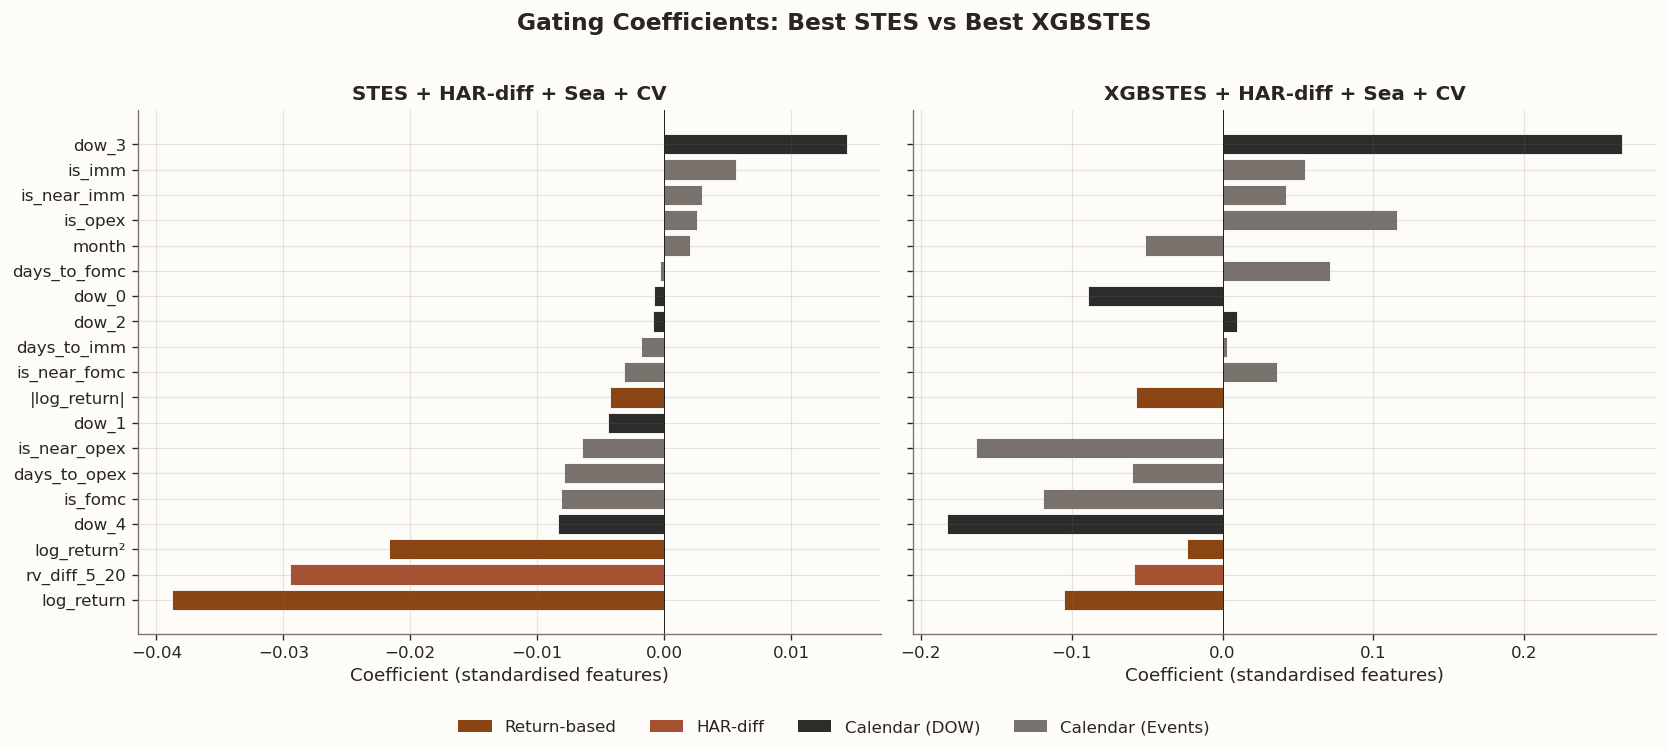

STES + HAR-diff + Sea + CV: β₀ = -1.7495  →  baseline α = σ(β₀) = 0.148
XGBSTES + HAR-diff + Sea + CV: β₀ = -0.3814  →  baseline α = σ(β₀) = 0.406

XGBSTES + HAR-diff + Seasonal + λ CV — Gating coefficients (descending |β|, excl. intercept):
  dow_3                 β = +0.264963  [Calendar (DOW)]
  dow_4                 β = -0.183004  [Calendar (DOW)]
  is_near_opex          β = -0.163599  [Calendar (Events)]
  is_fomc               β = -0.119076  [Calendar (Events)]
  is_opex               β = +0.115850  [Calendar (Events)]
  log_return            β = -0.105000  [Return-based]
  dow_0                 β = -0.089409  [Calendar (DOW)]
  days_to_fomc          β = +0.071386  [Calendar (Events)]
  days_to_opex          β = -0.060245  [Calendar (Events)]
  rv_diff_5_20          β = -0.058495  [HAR-diff]
  |log_return|          β = -0.057221  [Return-based]
  is_imm                β = +0.054435  [Calendar (Events)]
  month                 β = -0.051328  [Calendar (Events)]
  is_near_imm      

In [11]:
#| label: coefficient-extraction
#| code-fold: true
#| code-summary: "Extract and compare gating coefficients across models"

import json

# ── Helper: extract STES β vector as a dict ────────────────────────────
def _stes_coefs(model):
    return dict(zip(model.feature_names_, model.params))

# ── Helper: extract XGBoostSTES gblinear weights ────────────────────────
def _xgb_coefs(model):
    raw = json.loads(model.model_.save_raw("json"))
    weights = raw["learner"]["gradient_booster"]["model"]["weights"]
    # gblinear: [w_0, ..., w_{p-1}, bias]
    feat_names = model.model_.feature_names
    return dict(zip(feat_names, weights[: len(feat_names)]))

# ── Collect coefficients for all model variants ─────────────────────────
coef_records = []

model_specs = [
    ("STES baseline",              stes_parity,         _stes_coefs,  "STES"),
    ("STES + HAR-diff + CV",       stes_hdiff_cv,       _stes_coefs,  "STES"),
    ("STES + Seasonal + CV",       stes_sea_cv,         _stes_coefs,  "STES"),
    ("STES + HAR-diff + Sea + CV", stes_hdiff_sea_cv,   _stes_coefs,  "STES"),
    ("XGBSTES baseline",           xgbstes_e2e,         _xgb_coefs,   "XGBSTES"),
    ("XGBSTES + HAR-diff + CV",    xgbstes_e2e_hdiff_cv,_xgb_coefs,   "XGBSTES"),
    ("XGBSTES + Seasonal + CV",    xgbstes_sea_cv,      _xgb_coefs,   "XGBSTES"),
    ("XGBSTES + HAR-diff + Sea + CV", xgbstes_hdiff_sea_cv, _xgb_coefs, "XGBSTES"),
]

for label, mdl, extractor, family in model_specs:
    coefs = extractor(mdl)
    for feat, val in coefs.items():
        coef_records.append({"model": label, "family": family, "feature": feat, "coef": float(val)})

coef_df = pd.DataFrame(coef_records)

# ── Rename hash-based feature names to human-readable ───────────────────
import re

def _readable_name(f):
    """Map AlphaForge hash-based feature IDs to short labels."""
    if re.search(r"logret\.", f) and "abs" not in f and "sq" not in f:
        return "log_return"
    if re.search(r"abslogret\.", f):
        return "|log_return|"
    if re.search(r"sqlogret\.", f):
        return "log_return²"
    return f

coef_df["feature_label"] = coef_df["feature"].map(_readable_name)

# ── Group features into categories for display ──────────────────────────
def _feat_group(f):
    f_lower = f.lower()
    if any(k in f_lower for k in ["logret", "log_return", "const"]):
        return "Return-based"
    if "rv_diff" in f_lower or "rv5_har" in f_lower or "rv20_har" in f_lower:
        return "HAR-diff"
    if f_lower.startswith("dow_"):
        return "Calendar (DOW)"
    if any(k in f_lower for k in ["month", "fomc", "opex", "imm"]):
        return "Calendar (Events)"
    return "Other"

coef_df["group"] = coef_df["feature"].map(_feat_group)

# ── Plot: best STES vs best XGBSTES (HAR-diff + Seasonal + CV) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Group palette
group_colors = {
    "Return-based": BLOG_PALETTE[0],
    "HAR-diff": BLOG_PALETTE[1],
    "Calendar (DOW)": BLOG_PALETTE[2],
    "Calendar (Events)": BLOG_PALETTE[3],
    "Other": "#999999",
}

for ax, label in zip(axes, [
    "STES + HAR-diff + Sea + CV",
    "XGBSTES + HAR-diff + Sea + CV",
]):
    sub = coef_df[(coef_df["model"] == label)].copy()
    # Drop const (intercept) and near-zero features for readability
    sub = sub[(sub["feature"] != "const") & (sub["coef"].abs() > 1e-4)]
    sub = sub.sort_values("coef")
    colors = [group_colors.get(g, "#999999") for g in sub["group"]]
    ax.barh(sub["feature_label"], sub["coef"], color=colors, edgecolor="white", linewidth=0.5)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_xlabel("Coefficient (standardised features)")

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=g) for g, c in group_colors.items() if g != "Other"]
fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=False, fontsize=10)
fig.suptitle("Gating Coefficients: Best STES vs Best XGBSTES", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# ── Print intercept interpretation ───────────────────────────────────────
from scipy.special import expit as _expit

for mdl_label in ["STES + HAR-diff + Sea + CV", "XGBSTES + HAR-diff + Sea + CV"]:
    row = coef_df[(coef_df["model"] == mdl_label) & (coef_df["feature"] == "const")]
    if not row.empty:
        b0 = row["coef"].values[0]
        a0 = _expit(b0)
        print(f"{mdl_label}: β₀ = {b0:+.4f}  →  baseline α = σ(β₀) = {a0:.3f}")

# ── Print coefficient table for the best model (excluding const) ────────
best_coefs = coef_df[coef_df["model"] == "XGBSTES + HAR-diff + Sea + CV"].copy()
best_coefs = best_coefs[best_coefs["feature"] != "const"]
best_coefs = best_coefs.sort_values("coef", key=abs, ascending=False)
print("\nXGBSTES + HAR-diff + Seasonal + λ CV — Gating coefficients (descending |β|, excl. intercept):")
for _, row in best_coefs.iterrows():
    print(f"  {row['feature_label']:20s}  β = {row['coef']:+.6f}  [{row['group']}]")

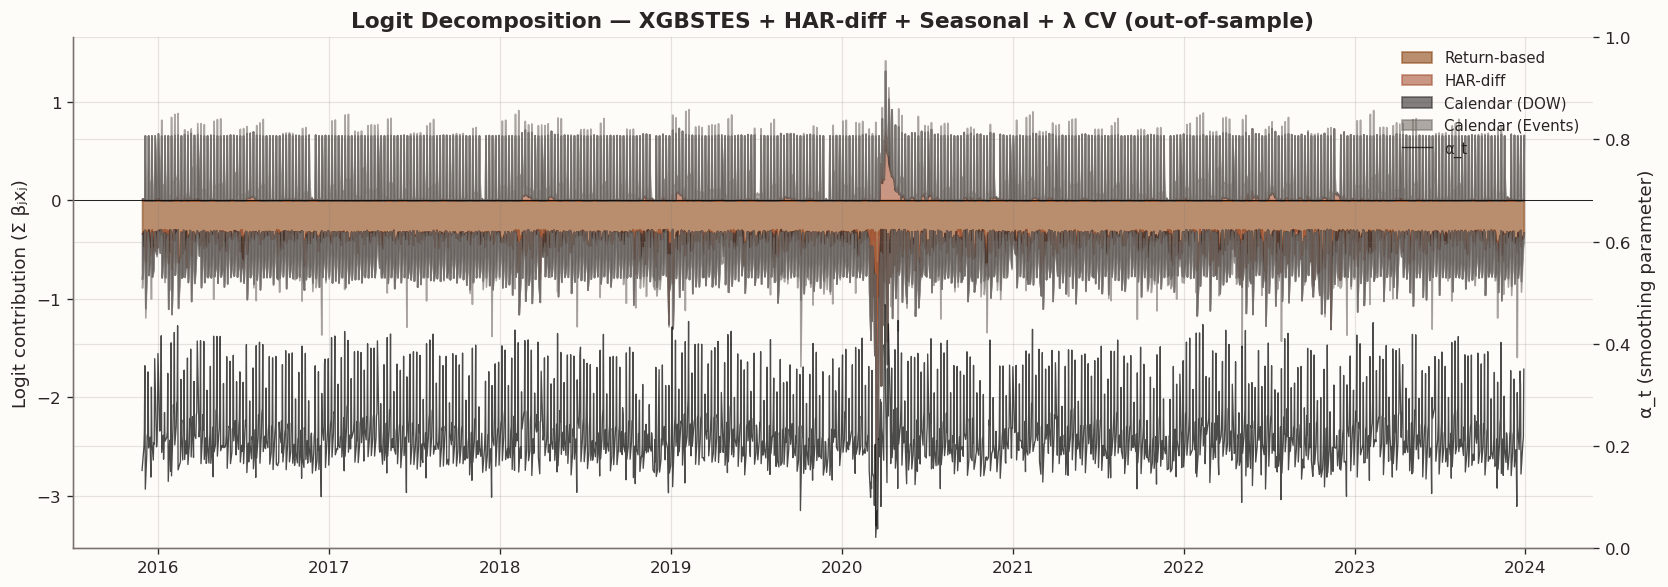

In [14]:
#| label: logit-decomposition
#| code-fold: true
#| code-summary: "Logit decomposition: per-feature contribution to α_t for the best model"

from scipy.special import expit

# ── Best model: XGBSTES + HAR-diff + Seasonal + λ CV ───────────────────
best_model = xgbstes_hdiff_sea_cv
best_X = X_all_hdiff_sea_s
best_coefs_dict = _xgb_coefs(best_model)

# Feature-level logit contributions: z_j(t) = β_j · x_j(t)
feat_names = list(best_coefs_dict.keys())
beta = np.array([best_coefs_dict[f] for f in feat_names])
X_np = best_X[feat_names].values
contributions = X_np * beta[np.newaxis, :]  # (T, p)
logit_total = contributions.sum(axis=1)     # Σ β_j x_j(t)

# Map features to groups
feat_groups = [_feat_group(f) for f in feat_names]
group_names = ["Return-based", "HAR-diff", "Calendar (DOW)", "Calendar (Events)"]
group_contrib = {}
for gname in group_names:
    mask = np.array([g == gname for g in feat_groups])
    if mask.any():
        group_contrib[gname] = contributions[:, mask].sum(axis=1)

# α_t from the model for overlay
alpha_best = best_model.get_alphas(best_X)

# ── Plot: OS period only (after train split) ────────────────────────────
os_start = PARITY_SPLIT_INDEX
idx_os = best_X.index[os_start:]

fig, ax1 = plt.subplots(figsize=(14, 5))

# Stacked area of logit contributions (absolute values for readability)
bottom_pos = np.zeros(len(idx_os))
bottom_neg = np.zeros(len(idx_os))

for gname in group_names:
    if gname not in group_contrib:
        continue
    vals = group_contrib[gname][os_start:]
    color = group_colors[gname]
    # Split positive/negative for cleaner stacking
    pos = np.maximum(vals, 0)
    neg = np.minimum(vals, 0)
    ax1.fill_between(idx_os, bottom_pos, bottom_pos + pos, alpha=0.6,
                     label=gname, color=color)
    ax1.fill_between(idx_os, bottom_neg + neg, bottom_neg, alpha=0.6,
                     color=color)
    bottom_pos += pos
    bottom_neg += neg

ax1.set_ylabel("Logit contribution (Σ βⱼxⱼ)")
ax1.axhline(0, color="black", linewidth=0.5)

# α_t overlay on right axis
ax2 = ax1.twinx()
ax2.plot(idx_os, alpha_best.iloc[os_start:], color="black", linewidth=0.8,
         alpha=0.7, label="α_t")
ax2.set_ylabel("α_t (smoothing parameter)")
ax2.set_ylim(0, 1)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper right", framealpha=0.9, fontsize=9)

ax1.set_title("Logit Decomposition — XGBSTES + HAR-diff + Seasonal + λ CV (out-of-sample)",
              fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

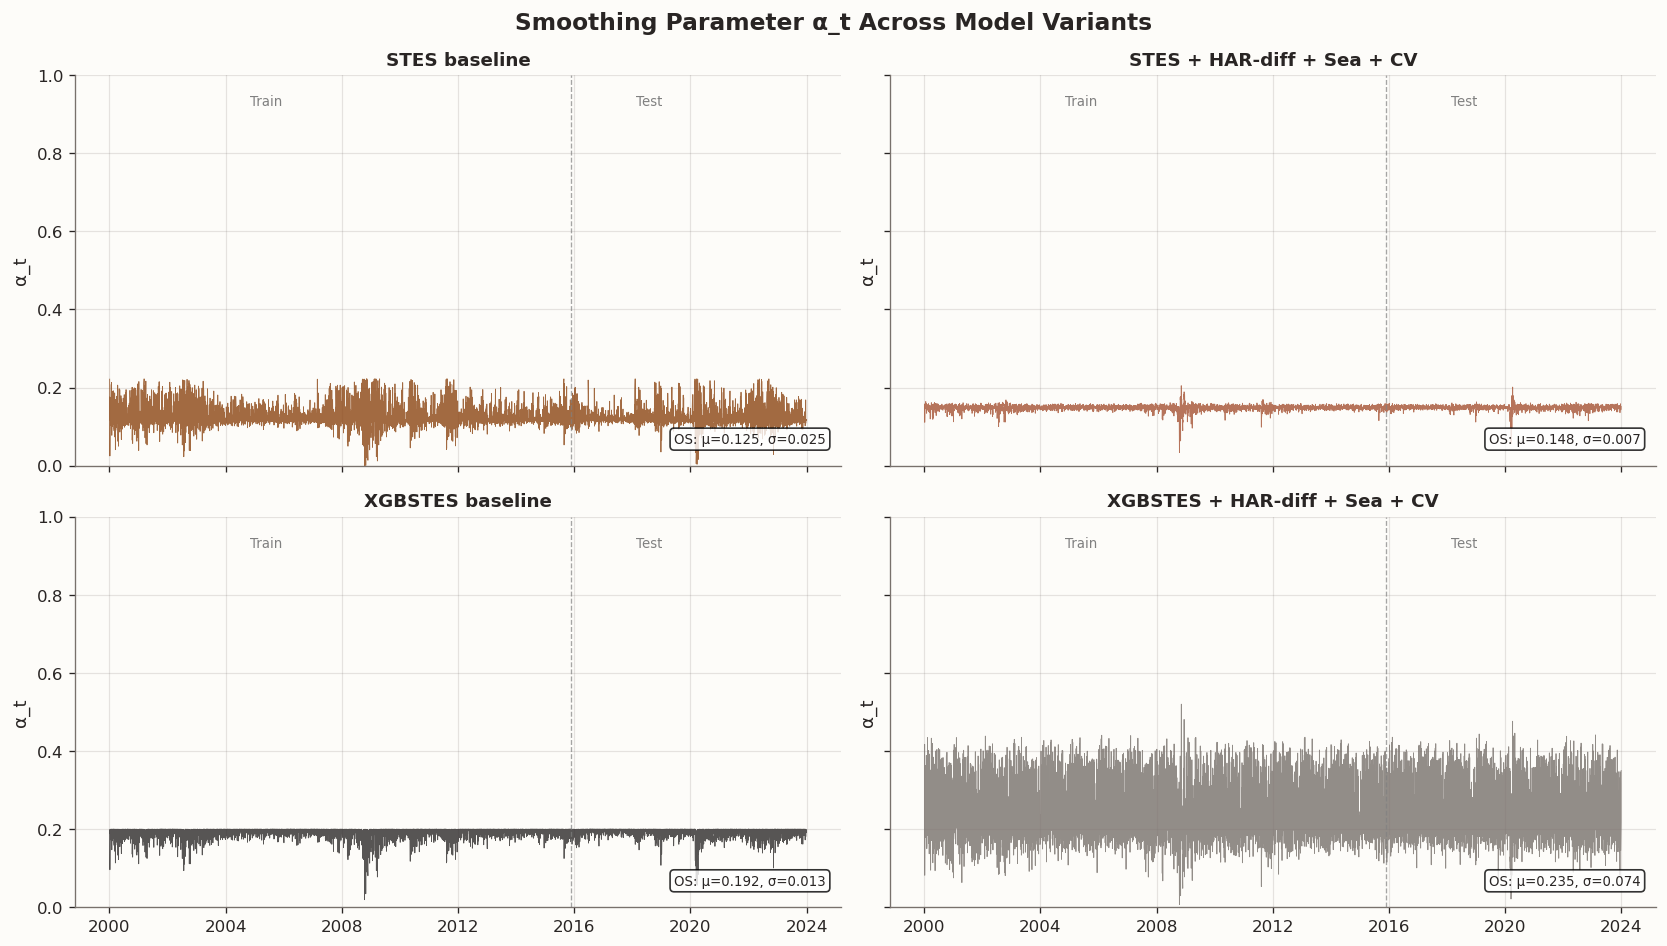

,OS Mean α,OS Std α,OS Min α,OS Max α
Model,,,,
STES baseline,0.1254,0.0254,0.0036,0.2222
STES + HAR-diff + Sea + CV,0.1483,0.0071,0.0560,0.2012
XGBSTES baseline,0.1917,0.0132,0.0565,0.2001
XGBSTES + HAR-diff + Sea + CV,0.2353,0.0738,0.0213,0.4764


In [15]:
#| label: alpha-comparison
#| code-fold: true
#| code-summary: "α_t time series comparison across model families"

# ── Extract α_t for four key models ─────────────────────────────────────
# STES models: predict_with_alpha returns (sigma2, alphas)
_, alpha_stes_base = stes_parity.predict_with_alpha(X_all_s, returns=r_all)
_, alpha_stes_full = stes_hdiff_sea_cv.predict_with_alpha(X_all_hdiff_sea_s, returns=r_all)

# XGBSTES models: get_alphas returns pd.Series
alpha_xgb_base = xgbstes_e2e.get_alphas(X_all_s)
alpha_xgb_full = xgbstes_hdiff_sea_cv.get_alphas(X_all_hdiff_sea_s)

# ── 2×2 panel: IS+OS for each model ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

alpha_series = [
    ("STES baseline", alpha_stes_base, BLOG_PALETTE[0]),
    ("STES + HAR-diff + Sea + CV", alpha_stes_full, BLOG_PALETTE[1]),
    ("XGBSTES baseline", alpha_xgb_base, BLOG_PALETTE[2]),
    ("XGBSTES + HAR-diff + Sea + CV", alpha_xgb_full, BLOG_PALETTE[3]),
]

for ax, (label, alpha, color) in zip(axes.flat, alpha_series):
    idx = X_all_s.index if len(alpha) == len(X_all_s) else X_all_hdiff_sea_s.index
    alpha_vals = np.asarray(alpha)
    ax.plot(idx, alpha_vals, color=color, linewidth=0.5, alpha=0.8)
    # Mark train/test boundary
    split_date = idx[PARITY_SPLIT_INDEX]
    ax.axvline(split_date, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_ylabel("α_t")
    # Annotate train/test regions
    ax.text(0.25, 0.95, "Train", transform=ax.transAxes,
            fontsize=8, color="gray", ha="center", va="top")
    ax.text(0.75, 0.95, "Test", transform=ax.transAxes,
            fontsize=8, color="gray", ha="center", va="top")

    # Summary statistics for OS period
    os_alpha = alpha_vals[PARITY_SPLIT_INDEX:]
    stats_text = f"OS: μ={os_alpha.mean():.3f}, σ={os_alpha.std():.3f}"
    ax.text(0.98, 0.05, stats_text, transform=ax.transAxes,
            fontsize=8, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

fig.suptitle("Smoothing Parameter α_t Across Model Variants",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

# ── Summary statistics table ────────────────────────────────────────────
alpha_stats = pd.DataFrame({
    "Model": [lbl for lbl, _, _ in alpha_series],
    "OS Mean α": [np.asarray(a)[PARITY_SPLIT_INDEX:].mean() for _, a, _ in alpha_series],
    "OS Std α": [np.asarray(a)[PARITY_SPLIT_INDEX:].std() for _, a, _ in alpha_series],
    "OS Min α": [np.asarray(a)[PARITY_SPLIT_INDEX:].min() for _, a, _ in alpha_series],
    "OS Max α": [np.asarray(a)[PARITY_SPLIT_INDEX:].max() for _, a, _ in alpha_series],
})
display(style_results_table(alpha_stats, precision=4, index_col="Model"))

### Discussion and conclusion

The coefficient analysis reveals a clear hierarchy in how the gating equation allocates its capacity.  The intercept $\beta_0$ dominates every model variant: in the STES family, $\sigma(\beta_0) \approx 0.15$, meaning the model defaults to very low $\alpha_t$ and trusts the accumulated exponential average; in XGBSTES, $\sigma(\beta_0) \approx 0.41$, a more moderate but still sub-half default.  This is the gating analogue of the HAR(22) coefficient dominating a standard HAR-RV regression — in both cases the model's strongest prior is that volatility is a slowly mean-reverting process, and the long-run average matters most.  All other features merely perturb $\alpha_t$ away from this baseline when there is evidence of a regime shift.

After the intercept, the return-based features — squared and absolute log-returns — carry the largest coefficients and serve as the primary perturbation channel.  Recent return magnitude is the main signal for pushing $\alpha_t$ upward: large moves cause the gate to open, weighting today's observation more heavily relative to the exponential history.  The HAR-diff feature adds a complementary layer of regime-transition information.  Its coefficient is consistently signed across both model families — a positive short-versus-long variance gap nudges the gate toward higher responsiveness — encoding momentum in the volatility process that single-day return features alone cannot capture.

Calendar and event-date features, by contrast, modulate rather than dominate.  The day-of-week and event-proximity coefficients are small relative to the return channel, and their contribution to the logit amounts to a gentle perturbation that typically shifts $\alpha_t$ by only a few percentage points.  This is the right behaviour: calendar structure should fine-tune the gating response, not override it.  The 12-model RMSE table confirms that these features are nevertheless incrementally valuable — the combined HAR-diff + Seasonal XGBSTES achieves the best out-of-sample RMSE (0.000438), with the logit decomposition attributing the marginal gain largely to FOMC-related features modulating $\alpha_t$ around scheduled volatility events.

Both STES and XGBSTES assign the same sign to every shared feature, but the XGBSTES coefficients are uniformly more attenuated — a consequence of `reg_lambda` regularisation in the `gblinear` booster.  Despite this shrinkage, XGBSTES achieves better out-of-sample performance, confirming that training $\boldsymbol{\beta}$ through the full variance recursion via end-to-end gradients matters more than raw coefficient magnitude.  The $\alpha_t$ time series comparison reinforces this point: XGBSTES produces a smoother, more concentrated smoothing-parameter path that nonetheless reaches higher peaks during genuine volatility events.

Finally, because both model families use a linear map into the logistic gate, there are no learned pairwise feature interactions — each feature's contribution to $\alpha_t$ is strictly additive in the logit space.  Introducing interaction terms such as day-of-week crossed with FOMC proximity is a natural extension, but would require either a non-linear booster or explicitly engineered interaction features.  We leave this, along with a broader multi-asset evaluation and rolling-window robustness checks, to future work.